# Hand classifier

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

C:\Users\Omistaja\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


tensorflow


In [2]:
from sklearn.model_selection import train_test_split
batch_size_n = 4
img_size = (224, 224)

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    'images/train',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    label_mode='categorical',
    validation_split=0.177, # ensures validation and test sets are equal size
    subset='both',
    shuffle=True,
    seed=123)

test_dataset = keras.utils.image_dataset_from_directory(
    'images/test',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    shuffle=False,
    label_mode='categorical')

Found 255 files belonging to 5 classes.
Using 210 files for training.
Using 45 files for validation.
Found 45 files belonging to 5 classes.


In [3]:
import tensorflow as tf
from keras.applications import VGG16
from keras import Sequential
from keras import layers
from keras.optimizers import Adam
num_classes = 5

conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# freeze lower layers
for layer in conv_base.layers[:-4]:
    layer.trainable = False
    
for layer in conv_base.layers[-4:]:
    layer.trainable = True

In [4]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [5]:
from keras.optimizers import Adam

model = Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    conv_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [6]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.1905 - loss: 3.3532 - val_accuracy: 0.2667 - val_loss: 1.6545
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.2190 - loss: 1.8957 - val_accuracy: 0.2889 - val_loss: 1.5581
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.2905 - loss: 1.6490 - val_accuracy: 0.3556 - val_loss: 1.4569
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.3381 - loss: 1.5486 - val_accuracy: 0.4222 - val_loss: 1.4121
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.3810 - loss: 1.4733 - val_accuracy: 0.3778 - val_loss: 1.3903
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.3952 - loss: 1.4198 - val_accuracy: 0.4000 - val_loss: 1.3735
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.3952 - loss: 1.3517 - val_accuracy: 0.4444 - val_loss: 1.2918
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.5048 - loss: 1.2447 - val_accuracy: 0.

In [7]:
images = []
labels = []
class_names = ['1 finger', '2 fingers', '3 fingers', '4 fingers', '5 fingers']

for image_batch, label_batch in test_dataset:
    images.append(image_batch.numpy())
    labels.append(label_batch.numpy())

images = np.concatenate(images)
labels = np.concatenate(labels)

In [8]:
def show_example_images_and_predictions(predicted_labels):
    plt.figure(figsize=(15, 8))
    
    for i in range(20):
        plt.subplot(4, 5, i + 1)
    
        plt.imshow(images[i].astype("uint8"))
    
        true_label = y_true_classes[i]
        pred_label = predicted_labels[i]
    
        color = "green" if true_label == pred_label else "red"
    
        plt.title(
            f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
            color=color
        )
    
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

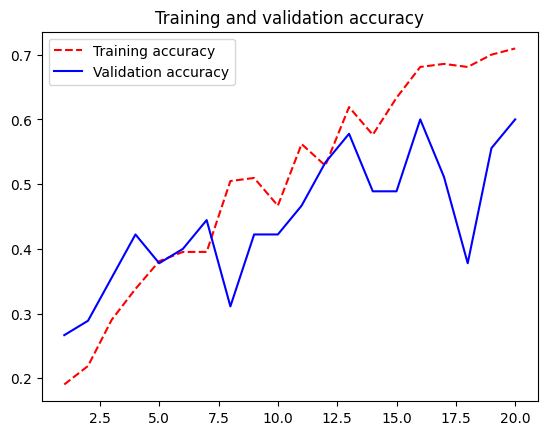

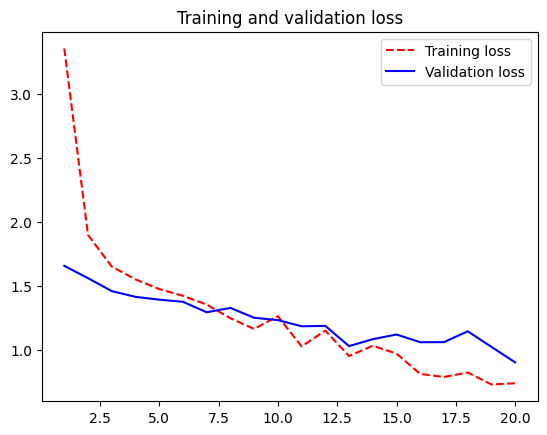

In [9]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [10]:
loss, acc = model.evaluate(test_dataset, verbose=0)
print(f"The model's test accuracy is {acc}")

The model's test accuracy is 0.5333333611488342


In [11]:
y_pred = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(np.concatenate([y for x, y in test_dataset], axis=0), axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


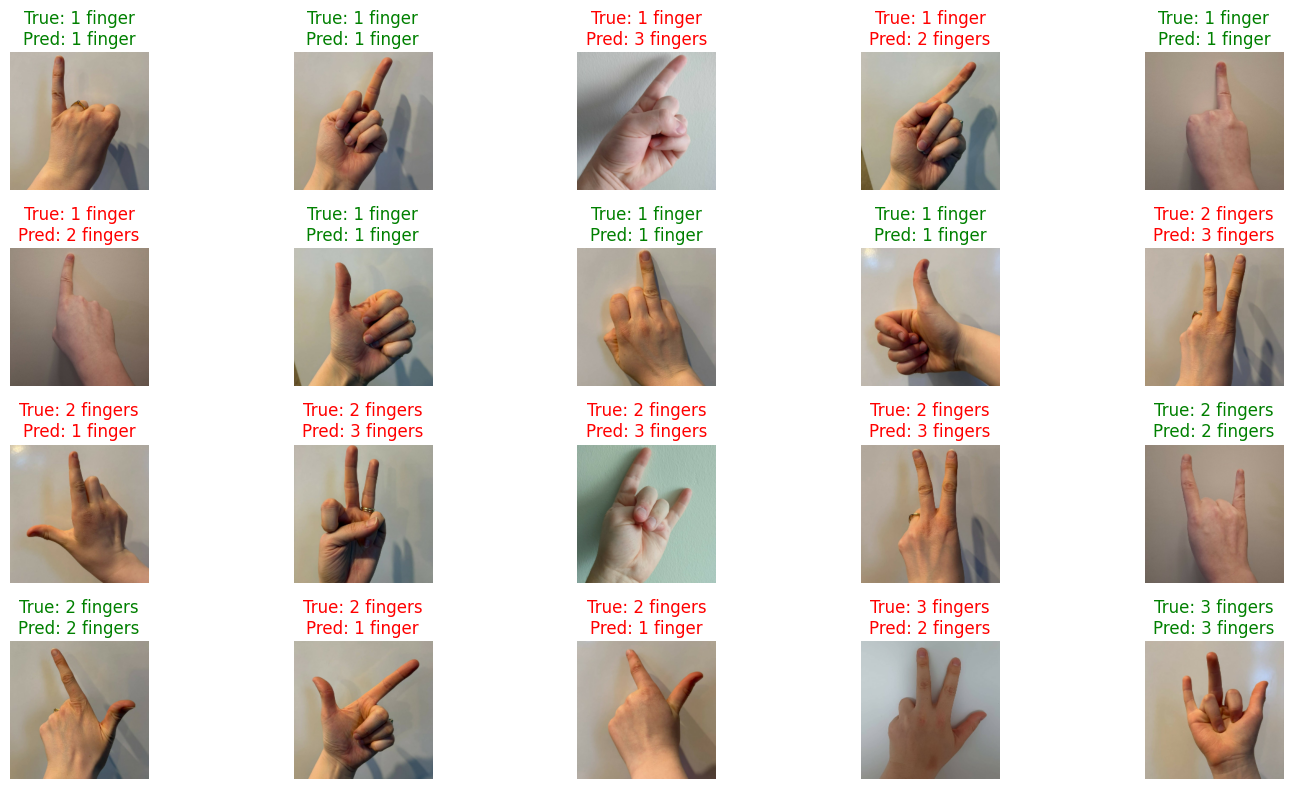

In [12]:
y_pred = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)
show_example_images_and_predictions(y_pred_classes)